In [ ]:
# Install the main computer vision library we will use
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

print("YOLOv8 loaded successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
YOLOv8 loaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2025-04-24 at 23.16.49_7ffddea5.jpg to WhatsApp Image 2025-04-24 at 23.16.49_7ffddea5.jpg


In [ ]:
results = model("WhatsApp Image 2025-04-24 at 23.16.49_7ffddea5.jpg")

print("Detection complete!")


image 1/1 /content/WhatsApp Image 2025-04-24 at 23.16.49_7ffddea5.jpg: 384x640 4 persons, 356.8ms
Speed: 12.1ms preprocess, 356.8ms inference, 35.6ms postprocess per image at shape (1, 3, 384, 640)
Detection complete!


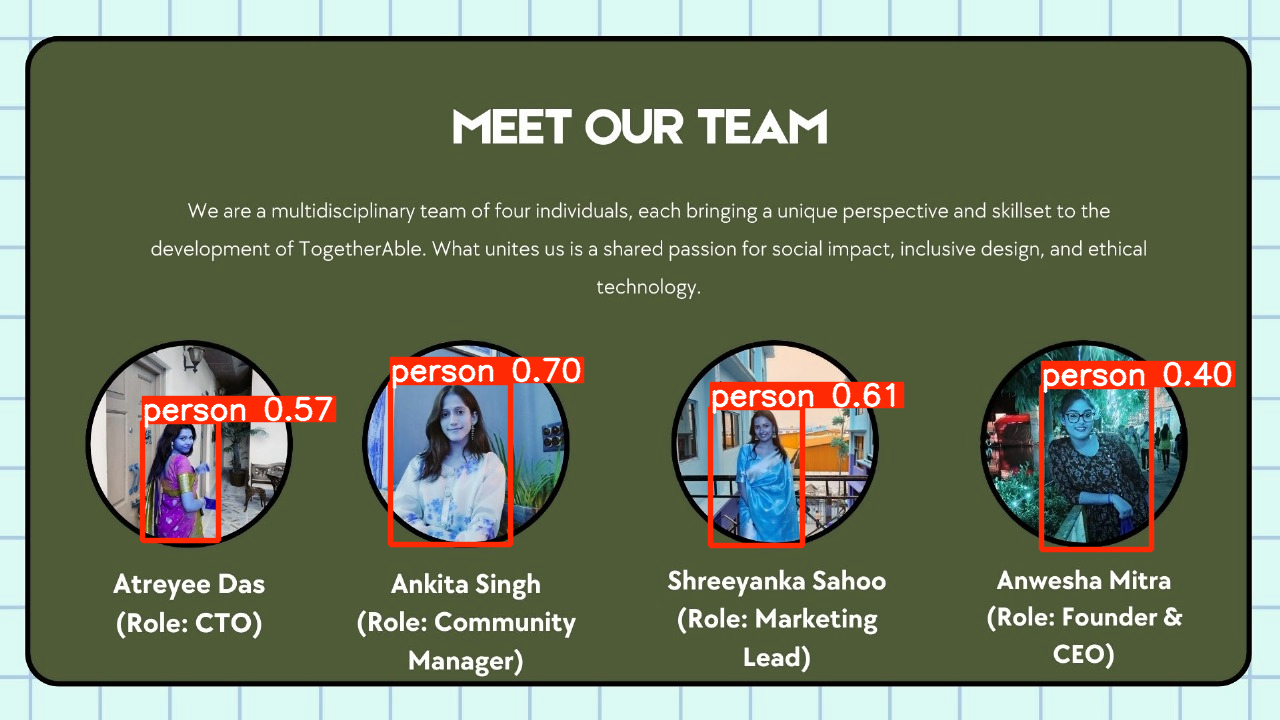

In [ ]:
from PIL import Image
from IPython.display import display

# Show the image with YOLO detections
annotated_image = results[0].plot()

display(Image.fromarray(annotated_image))

In [ ]:
# Get detection data from YOLO
boxes = results[0].boxes

# COCO class ID for "person" is 0
for i in range(len(boxes)):
    class_id = int(boxes.cls[i])

    if class_id == 0:
        x1, y1, x2, y2 = boxes.xyxy[i].tolist()
        confidence = float(boxes.conf[i])

        print(
            f"Person {i + 1}: "
            f"x1={x1:.1f}, y1={y1:.1f}, "
            f"x2={x2:.1f}, y2={y2:.1f}, "
            f"confidence={confidence:.2f}"
        )

Person 1: x1=390.6, y1=382.9, x2=510.9, y2=544.3, confidence=0.70
Person 2: x1=710.6, y1=407.4, x2=802.7, y2=545.4, confidence=0.61
Person 3: x1=142.1, y1=421.5, x2=218.2, y2=540.6, confidence=0.57
Person 4: x1=1041.4, y1=386.8, x2=1151.8, y2=549.6, confidence=0.40


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4 to WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4


In [ ]:
from ultralytics import YOLO

# Load YOLOv8
model = YOLO("yolov8n.pt")

# Your uploaded video
video_path = "WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"

# Run YOLO on the video
results = model.predict(
    source=video_path,
    classes=[0],      # 0 = person
    conf=0.4,
    vid_stride=4,    # ~15 FPS if source is ~60 FPS
    save=True,
    show=False
)

print("Video processing completed!")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 169.8ms
video 1/1 (frame 2/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 2 persons, 155.9ms
video 1/1 (frame 3/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 2 persons, 152.0ms
video 1/1 (frame 4/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 151.7ms
video 1/1 (frame 5/308) /content/WhatsApp

In [ ]:
from ultralytics import YOLO

# Load YOLOv8
model = YOLO("yolov8n.pt")

# Your video
video_path = "WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"

# Run YOLOv8 + ByteTrack
results = model.track(
    source=video_path,
    classes=[0],       # person only
    conf=0.4,
    tracker="bytetrack.yaml",
    vid_stride=4,
    save=True,
    show=False,
    stream=True
)

# Read through the tracking results
for frame_number, result in enumerate(results):
    boxes = result.boxes

    if boxes.id is not None:
        track_ids = boxes.id.int().cpu().tolist()

        print(f"Frame {frame_number}: IDs = {track_ids}")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 387ms
Prepared 1 package in 95ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


video 1/1 (frame 1/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 143.6ms
Frame 0: IDs = [1]
video 1/1 (frame 2/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 143.2ms
Frame 1: IDs = [1]
video 1/1 (frame 3/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 144.0ms
Frame 2: IDs = [1]
video 1/1 (frame 4/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 149.5ms
Frame 3: IDs = [1]
video 1/1 (frame 5/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 147.5ms
Frame 4: IDs = [1]
video 1/1 (frame 6/308) /co

In [ ]:
import csv
import cv2
from ultralytics import YOLO

# Load model
model = YOLO("yolov8n.pt")

# Video
video_path = "WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"

# Open video to get FPS
cap = cv2.VideoCapture(video_path)
video_fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

print("Original video FPS:", video_fps)

# Output CSV
csv_path = "customer_tracking_data.csv"

# Run YOLO + ByteTrack
results = model.track(
    source=video_path,
    classes=[0],
    conf=0.4,
    tracker="bytetrack.yaml",
    vid_stride=4,
    stream=True
)

# Create CSV
with open(csv_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "frame",
        "time_seconds",
        "track_id",
        "x1",
        "y1",
        "x2",
        "y2",
        "center_x",
        "center_y",
        "confidence"
    ])

    for frame_number, result in enumerate(results):

        boxes = result.boxes

        if boxes.id is None:
            continue

        track_ids = boxes.id.int().cpu().tolist()
        coordinates = boxes.xyxy.cpu().tolist()
        confidences = boxes.conf.cpu().tolist()

        for track_id, box, confidence in zip(
            track_ids,
            coordinates,
            confidences
        ):

            x1, y1, x2, y2 = box

            # Center of the person's bounding box
            center_x = (x1 + x2) / 2
            center_y = (y1 + y2) / 2

            # Because we process every 4th frame
            time_seconds = (frame_number * 4) / video_fps

            writer.writerow([
                frame_number,
                round(time_seconds, 3),
                track_id,
                round(x1, 2),
                round(y1, 2),
                round(x2, 2),
                round(y2, 2),
                round(center_x, 2),
                round(center_y, 2),
                round(confidence, 3)
            ])

print("Tracking complete!")
print("Saved:", csv_path)

Original video FPS: 60.00246363437937

video 1/1 (frame 1/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 147.9ms
video 1/1 (frame 2/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 163.5ms
video 1/1 (frame 3/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 144.7ms
video 1/1 (frame 4/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 146.1ms
video 1/1 (frame 5/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 143.4ms
video 1/1 (frame 6/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 218.2ms
video 1/1 (frame 7/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 1 person, 231.9ms
video 1/1 (frame 8/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 2 persons, 222.7ms
video 1/1 (frame 9/308) /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4: 640x384 2 persons, 229.2ms
video 1/1 (frame 10/308

In [ ]:
import pandas as pd

# Load our tracking dataset
df = pd.read_csv("customer_tracking_data.csv")

print("Number of rows:", len(df))
print("Number of unique customers:", df["track_id"].nunique())

# Show the first 10 rows
display(df.head(10))

Number of rows: 502
Number of unique customers: 7


,frame,time_seconds,track_id,x1,y1,x2,y2,center_x,center_y,confidence
0,0,0.000,1,185.04,271.87,400.91,848.80,292.97,560.34,0.871
1,1,0.067,1,176.59,271.03,393.22,849.12,284.91,560.07,0.804
2,2,0.133,1,172.19,268.24,389.51,848.99,280.85,558.62,0.814
3,3,0.200,1,161.58,261.46,381.56,848.23,271.57,554.84,0.839
4,4,0.267,1,156.62,254.90,379.74,847.70,268.18,551.30,0.810
5,5,0.333,1,159.17,245.30,387.60,848.49,273.39,546.89,0.803
6,6,0.400,1,167.16,232.59,401.98,848.95,284.57,540.77,0.825
7,7,0.467,1,171.48,218.95,412.91,849.22,292.19,534.09,0.843
8,7,0.467,4,0.00,316.70,109.20,804.77,54.60,560.74,0.613
9,8,0.533,1,170.60,209.52,416.81,849.29,293.71,529.40,0.885


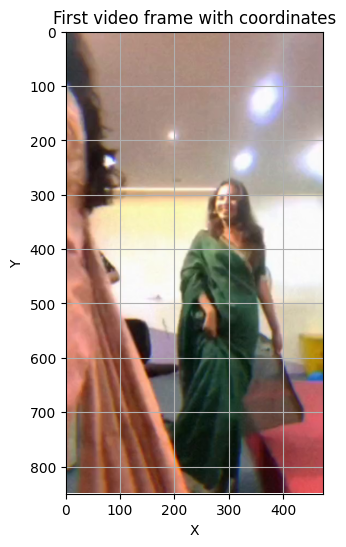

In [ ]:
import cv2
import matplotlib.pyplot as plt

video_path = "WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(frame)
    plt.xlim(0, frame.shape[1])
    plt.ylim(frame.shape[0], 0)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("First video frame with coordinates")
    plt.grid()
    plt.show()
else:
    print("Could not read the video.")

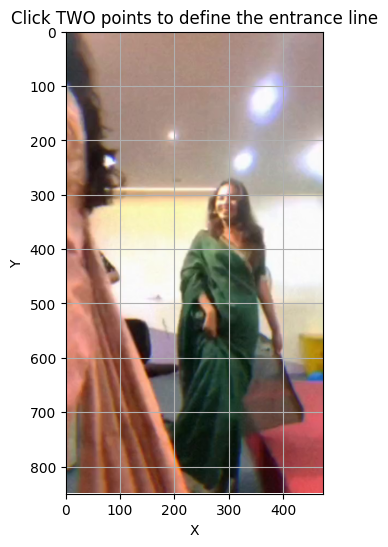

In [ ]:
import cv2
import matplotlib.pyplot as plt

video_path = "WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(frame_rgb)
    ax.set_xlim(0, frame.shape[1])
    ax.set_ylim(frame.shape[0], 0)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("Click TWO points to define the entrance line")
    ax.grid()

    points = []

    def onclick(event):
        if event.xdata is not None and event.ydata is not None:
            if len(points) < 2:
                x = int(event.xdata)
                y = int(event.ydata)
                points.append((x, y))

                ax.plot(x, y, 'ro')
                ax.annotate(
                    f"({x}, {y})",
                    (x, y),
                    xytext=(10, -10),
                    textcoords="offset points"
                )

                fig.canvas.draw()

                print(f"Point {len(points)}: ({x}, {y})")

                if len(points) == 2:
                    print("\nEntrance line coordinates:")
                    print(f"Point 1 = {points[0]}")
                    print(f"Point 2 = {points[1]}")
                    print("\nThese coordinates will be used for footfall counting.")

    fig.canvas.mpl_connect('button_press_event', onclick)
    plt.show()

else:
    print("Could not read the video.")

FPS: 60.00
Total frames: 1234
Duration: 20.57 seconds


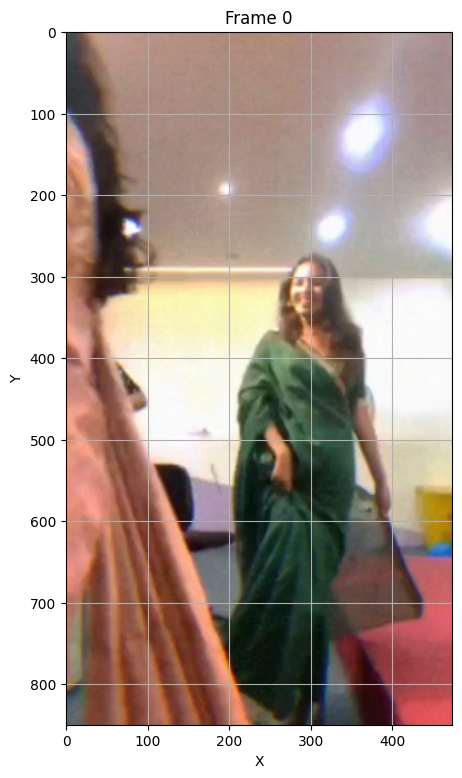

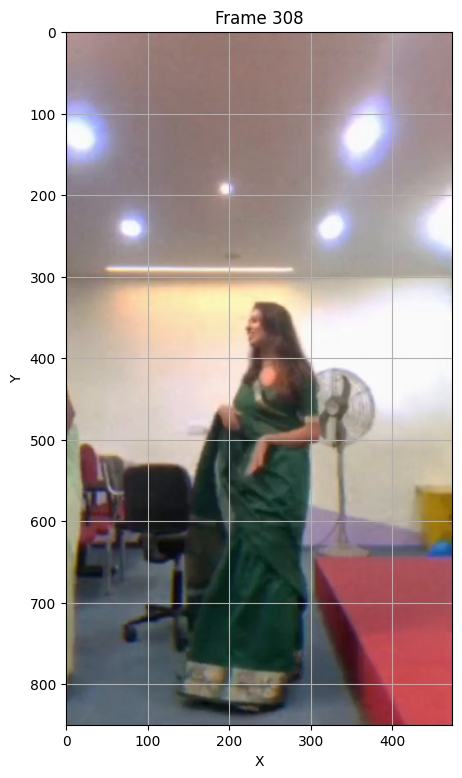

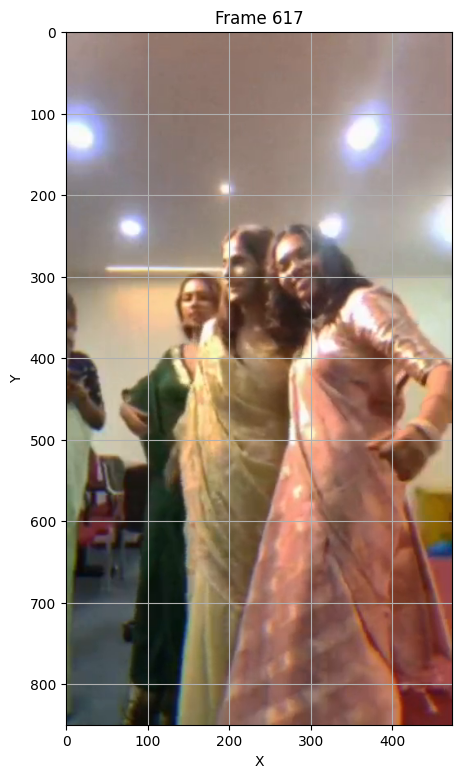

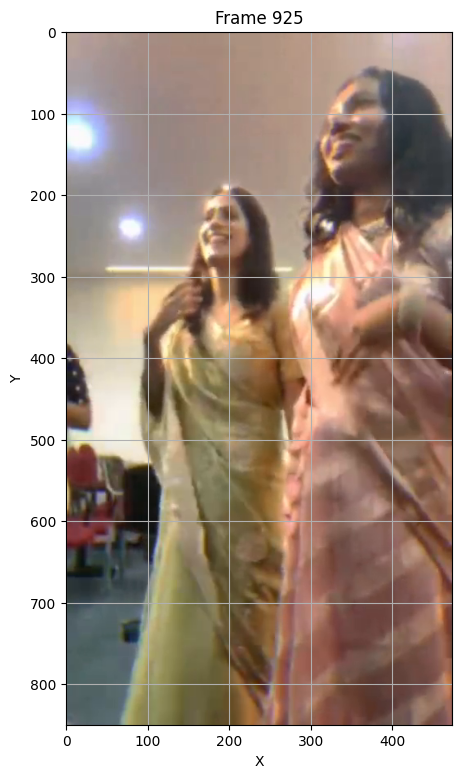

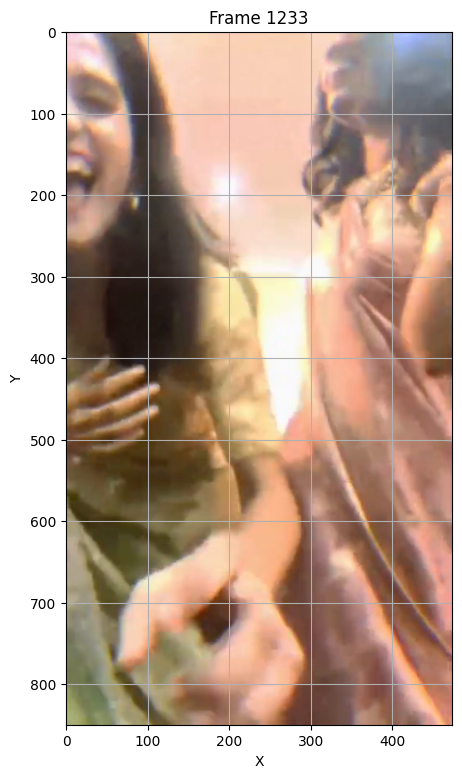

In [ ]:
import cv2
import matplotlib.pyplot as plt

video_path = "WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"

cap = cv2.VideoCapture(video_path)

# Get video information
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps if fps > 0 else 0

print(f"FPS: {fps:.2f}")
print(f"Total frames: {total_frames}")
print(f"Duration: {duration:.2f} seconds")

# Select frames from different parts of the video
frame_numbers = [
    0,
    int(total_frames * 0.25),
    int(total_frames * 0.50),
    int(total_frames * 0.75),
    total_frames - 1
]

frames = []

for frame_no in frame_numbers:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
    ret, frame = cap.read()

    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((frame_no, frame))

cap.release()

# Display frames
for frame_no, frame in frames:
    plt.figure(figsize=(7, 9))
    plt.imshow(frame)
    plt.title(f"Frame {frame_no}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()
    plt.show()

In [ ]:
!pip install ultralytics -q

In [ ]:
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


FPS: 60.00246363437937
Total frames: 1234
Duration: 20.57 seconds


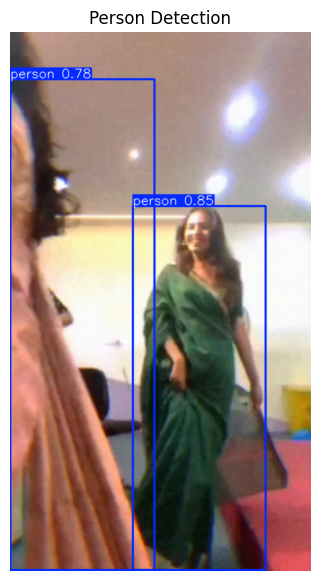

In [ ]:
import cv2
from ultralytics import YOLO

# Video
video_path = "WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"

# Load video
cap = cv2.VideoCapture(video_path)

# Check video
if not cap.isOpened():
    print("Could not open video.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print("FPS:", fps)
    print("Total frames:", total_frames)
    print("Duration:", round(total_frames / fps, 2), "seconds")

    # Read first frame
    ret, frame = cap.read()
    cap.release()

    if ret:
        # Run YOLO detection
        results = model(frame, classes=[0], verbose=False)

        # Draw detections
        annotated_frame = results[0].plot()

        # Display
        from matplotlib import pyplot as plt

        plt.figure(figsize=(10, 7))
        plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title("Person Detection")
        plt.show()

In [ ]:
# Improved BoT-SORT tracker with ReID

tracker_config = """
tracker_type: botsort

track_high_thresh: 0.3
track_low_thresh: 0.1
new_track_thresh: 0.4

track_buffer: 300
match_thresh: 0.8

fuse_score: True

gmc_method: none

proximity_thresh: 0.3
appearance_thresh: 0.75

with_reid: True
model: auto
"""

with open("custom_botsort.yaml", "w") as f:
    f.write(tracker_config)

print("Improved BoT-SORT + ReID tracker created!")

Improved BoT-SORT + ReID tracker created!


In [ ]:
# ============================================================
# STEP 1: PERSON DETECTION + TRACKING DIAGNOSTIC
# DO NOT ADD FOOTFALL LOGIC YET
# ============================================================

!pip install ultralytics -q

import cv2
import os
from ultralytics import YOLO

# ------------------------------------------------------------
# FIND VIDEO
# ------------------------------------------------------------
# If VIDEO_PATH already exists from an earlier cell, use it.
# Otherwise, automatically look for a video in /content.

if "VIDEO_PATH" not in globals() or not os.path.exists(VIDEO_PATH):
    video_files = []

    for file in os.listdir("/content"):
        if file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            video_files.append(os.path.join("/content", file))

    if len(video_files) == 0:
        raise FileNotFoundError(
            "No video file was found in /content. "
            "Upload your video first."
        )

    VIDEO_PATH = video_files[0]

print("VIDEO:", VIDEO_PATH)

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
OUTPUT_PATH = "/content/tracking_test.mp4"

# ------------------------------------------------------------
# MODEL
# YOLOv8s is more accurate than YOLOv8n
# ------------------------------------------------------------
model = YOLO("yolov8s.pt")

# ------------------------------------------------------------
# READ VIDEO INFORMATION
# ------------------------------------------------------------
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Could not open the video.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Video size:", width, "x", height)
print("Total frames:", total_frames)

cap.release()

# ------------------------------------------------------------
# VIDEO WRITER
# ------------------------------------------------------------
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    fps,
    (width, height)
)

# ------------------------------------------------------------
# TRACKING
# ByteTrack is intentionally used here.
# It gives us a clean baseline before adding identity logic.
# ------------------------------------------------------------
results = model.track(
    source=VIDEO_PATH,
    persist=True,
    tracker="bytetrack.yaml",
    classes=[0],       # person only
    conf=0.40,
    iou=0.50,
    stream=True,
    verbose=False
)

frame_number = 0
all_track_ids = set()

# ------------------------------------------------------------
# PROCESS VIDEO
# ------------------------------------------------------------
for result in results:

    frame_number += 1

    frame = result.orig_img.copy()

    if result.boxes is not None and result.boxes.id is not None:

        boxes = result.boxes.xyxy.cpu().numpy()
        track_ids = result.boxes.id.cpu().numpy().astype(int)

        for box, track_id in zip(boxes, track_ids):

            x1, y1, x2, y2 = box.astype(int)

            all_track_ids.add(int(track_id))

            # Draw bounding box
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # Draw TRACK ID
            cv2.putText(
                frame,
                f"ID {track_id}",
                (x1, max(25, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 0, 0),
                2
            )

    # --------------------------------------------------------
    # Display information
    # --------------------------------------------------------
    cv2.putText(
        frame,
        f"Frame: {frame_number}",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 255, 255),
        2
    )

    cv2.putText(
        frame,
        f"Current people: {len(result.boxes) if result.boxes is not None else 0}",
        (20, 70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    out.write(frame)

    # Print progress every 100 frames
    if frame_number % 100 == 0:
        print(
            f"Processed {frame_number}/{total_frames} frames | "
            f"Tracker IDs seen: {sorted(all_track_ids)}"
        )

# ------------------------------------------------------------
# FINISH
# ------------------------------------------------------------
out.release()

print()
print("==============================================")
print("TRACKING TEST COMPLETE")
print("==============================================")
print("Output video:", OUTPUT_PATH)
print("Unique tracker IDs seen:", sorted(all_track_ids))
print("Number of tracker IDs:", len(all_track_ids))
print("==============================================")

VIDEO: /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4
FPS: 60.00246363437937
Video size: 474 x 850
Total frames: 1234
Processed 100/1234 frames | Tracker IDs seen: [1, 2, 3]
Processed 200/1234 frames | Tracker IDs seen: [1, 2, 3, 8, 9, 10]
Processed 300/1234 frames | Tracker IDs seen: [1, 2, 3, 8, 9, 10]
Processed 400/1234 frames | Tracker IDs seen: [1, 2, 3, 8, 9, 10, 11, 15]
Processed 500/1234 frames | Tracker IDs seen: [1, 2, 3, 8, 9, 10, 11, 15, 16, 18]
Processed 600/1234 frames | Tracker IDs seen: [1, 2, 3, 8, 9, 10, 11, 15, 16, 18]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# RETAIL FOOTFALL - CUSTOM LIGHTWEIGHT TRACKER
# ============================================================

!pip install ultralytics -q

import cv2
import os
import numpy as np
from ultralytics import YOLO

# ============================================================
# CONFIGURATION
# ============================================================

VIDEO_PATH = "/content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"
OUTPUT_PATH = "/content/final_footfall_output.mp4"

MODEL_PATH = "yolov8s.pt"

# Your entrance line from the previous tests
ENTRANCE_Y = 637

# We use a zone around the entrance instead of one exact pixel
ZONE_SIZE = 45

# In your video, entering appears to be downward.
# If the final test shows the opposite, we will change this.
ENTRY_DIRECTION = "DOWN"

# Process every Nth frame.
# 2 = every second frame, approximately 30 FPS for your video.
FRAME_SKIP = 2

# How many processed frames a person can disappear
# before we consider that track lost.
MAX_MISSED = 12

# Maximum movement between two detections
MAX_DISTANCE = 120

# Detection confidence
CONFIDENCE = 0.40


# ============================================================
# CHECK VIDEO
# ============================================================

if not os.path.exists(VIDEO_PATH):
    # Automatically find the video if the exact filename changed
    candidates = [
        os.path.join("/content", f)
        for f in os.listdir("/content")
        if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))
    ]

    if not candidates:
        raise FileNotFoundError(
            "No video file found in /content."
        )

    VIDEO_PATH = candidates[0]

print("VIDEO:", VIDEO_PATH)


# ============================================================
# LOAD MODEL
# ============================================================

model = YOLO(MODEL_PATH)

print("YOLO model loaded.")


# ============================================================
# OPEN VIDEO
# ============================================================

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Could not open video.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Size:", width, "x", height)
print("Total frames:", total_frames)

# Output keeps original FPS
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    fps,
    (width, height)
)


# ============================================================
# SIMPLE TRACK OBJECT
# ============================================================

class Track:

    def __init__(self, track_id, box, frame_number):

        self.id = track_id

        self.box = box

        self.last_frame = frame_number

        self.missed = 0

        # Center point
        self.center_history = []

        # Bottom-center point.
        # This is what we use for entrance crossing.
        self.foot_history = []

        # Crossing state
        self.was_outside = False
        self.was_inside = False

        self.counted = False

        self.update_position(box)


    def update_position(self, box):

        self.box = box

        x1, y1, x2, y2 = box

        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        # Bottom-center = approximate foot position
        fx = (x1 + x2) / 2
        fy = y2

        self.center_history.append((cx, cy))
        self.foot_history.append((fx, fy))

        # Keep history small
        if len(self.center_history) > 30:
            self.center_history.pop(0)

        if len(self.foot_history) > 30:
            self.foot_history.pop(0)


# ============================================================
# TRACK MANAGEMENT
# ============================================================

tracks = {}

next_track_id = 1

footfall = 0

counted_track_ids = set()


def center_of_box(box):

    x1, y1, x2, y2 = box

    return np.array([
        (x1 + x2) / 2,
        (y1 + y2) / 2
    ])


def distance_between(box1, box2):

    c1 = center_of_box(box1)
    c2 = center_of_box(box2)

    return float(np.linalg.norm(c1 - c2))


# ============================================================
# ENTRANCE ZONE
# ============================================================

UPPER_LINE = ENTRANCE_Y - ZONE_SIZE
LOWER_LINE = ENTRANCE_Y + ZONE_SIZE


def get_zone(y):

    if y < UPPER_LINE:
        return "OUTSIDE"

    if y > LOWER_LINE:
        return "INSIDE"

    return "ZONE"


# ============================================================
# CROSSING CHECK
# ============================================================

def check_crossing(track):

    global footfall

    if track.counted:
        return

    if len(track.foot_history) < 3:
        return

    # Look at recent foot positions
    recent = track.foot_history[-8:]

    zones = [
        get_zone(point[1])
        for point in recent
    ]

    # Remove ambiguous zone positions
    clean_zones = [
        z for z in zones
        if z != "ZONE"
    ]

    if len(clean_zones) < 3:
        return

    # --------------------------------------------------------
    # DOWNWARD ENTRY
    # OUTSIDE -> INSIDE
    # --------------------------------------------------------

    if ENTRY_DIRECTION == "DOWN":

        has_outside = "OUTSIDE" in clean_zones[:-1]
        currently_inside = clean_zones[-1] == "INSIDE"

        if has_outside and currently_inside:

            track.counted = True

            footfall += 1

            counted_track_ids.add(track.id)

            print(
                f"ENTRY COUNTED -> Track {track.id} | "
                f"Total footfall = {footfall}"
            )

    # --------------------------------------------------------
    # UPWARD ENTRY
    # INSIDE -> OUTSIDE
    # --------------------------------------------------------

    else:

        has_inside = "INSIDE" in clean_zones[:-1]
        currently_outside = clean_zones[-1] == "OUTSIDE"

        if has_inside and currently_outside:

            track.counted = True

            footfall += 1

            counted_track_ids.add(track.id)

            print(
                f"ENTRY COUNTED -> Track {track.id} | "
                f"Total footfall = {footfall}"
            )


# ============================================================
# MAIN VIDEO LOOP
# ============================================================

frame_number = 0

processed_frames = 0

all_track_ids = set()


while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # --------------------------------------------------------
    # Skip frames to make processing faster
    # --------------------------------------------------------

    if frame_number % FRAME_SKIP != 0:

        # Still write the frame
        out.write(frame)

        continue

    processed_frames += 1

    # --------------------------------------------------------
    # YOLO PERSON DETECTION
    # --------------------------------------------------------

    result = model.predict(
        frame,
        classes=[0],       # person only
        conf=CONFIDENCE,
        verbose=False
    )[0]

    detections = []

    if result.boxes is not None:

        boxes = result.boxes.xyxy.cpu().numpy()

        for box in boxes:

            x1, y1, x2, y2 = box

            # Keep coordinates inside frame
            x1 = max(0, min(width - 1, int(x1)))
            y1 = max(0, min(height - 1, int(y1)))
            x2 = max(0, min(width - 1, int(x2)))
            y2 = max(0, min(height - 1, int(y2)))

            detections.append(
                np.array([x1, y1, x2, y2])
            )


    # ========================================================
    # MATCH DETECTIONS TO OUR OWN TRACKS
    # ========================================================

    unmatched_detections = set(range(len(detections)))

    unmatched_tracks = set(tracks.keys())

    matches = []


    # Build possible matches
    possible_matches = []

    for tid in tracks:

        track = tracks[tid]

        for di, detection in enumerate(detections):

            distance = distance_between(
                track.box,
                detection
            )

            if distance <= MAX_DISTANCE:

                possible_matches.append(
                    (distance, tid, di)
                )


    # Closest matches first
    possible_matches.sort(
        key=lambda x: x[0]
    )


    # Assign detections
    for distance, tid, di in possible_matches:

        if tid not in unmatched_tracks:
            continue

        if di not in unmatched_detections:
            continue

        matches.append(
            (tid, di)
        )

        unmatched_tracks.remove(tid)
        unmatched_detections.remove(di)


    # ========================================================
    # UPDATE MATCHED TRACKS
    # ========================================================

    for tid, di in matches:

        track = tracks[tid]

        track.update_position(
            detections[di]
        )

        track.last_frame = frame_number

        track.missed = 0

        check_crossing(track)


    # ========================================================
    # CREATE NEW TRACKS
    # ========================================================

    for di in unmatched_detections:

        new_track = Track(
            next_track_id,
            detections[di],
            frame_number
        )

        tracks[next_track_id] = new_track

        all_track_ids.add(next_track_id)

        next_track_id += 1


    # ========================================================
    # MARK MISSED TRACKS
    # ========================================================

    for tid in list(unmatched_tracks):

        tracks[tid].missed += 1


    # Remove tracks that disappeared for too long
    for tid in list(tracks.keys()):

        if tracks[tid].missed > MAX_MISSED:

            del tracks[tid]


    # ========================================================
    # DRAW ENTRANCE ZONE
    # ========================================================

    cv2.line(
        frame,
        (0, UPPER_LINE),
        (width, UPPER_LINE),
        (255, 255, 0),
        2
    )

    cv2.line(
        frame,
        (0, ENTRANCE_Y),
        (width, ENTRANCE_Y),
        (0, 0, 255),
        3
    )

    cv2.line(
        frame,
        (0, LOWER_LINE),
        (width, LOWER_LINE),
        (255, 255, 0),
        2
    )


    # ========================================================
    # DRAW TRACKS
    # ========================================================

    for tid, track in tracks.items():

        x1, y1, x2, y2 = track.box.astype(int)

        if track.counted:

            box_color = (0, 255, 0)

        else:

            box_color = (255, 165, 0)


        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            box_color,
            2
        )


        # Bottom center / foot point
        fx = int((x1 + x2) / 2)
        fy = int(y2)

        cv2.circle(
            frame,
            (fx, fy),
            6,
            (0, 255, 255),
            -1
        )


        label = f"Person {tid}"

        if track.counted:
            label += " [COUNTED]"


        cv2.putText(
            frame,
            label,
            (x1, max(25, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            box_color,
            2
        )


    # ========================================================
    # FOOTFALL DISPLAY
    # ========================================================

    cv2.putText(
        frame,
        f"TOTAL FOOTFALL: {footfall}",
        (20, 45),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 0),
        3
    )


    cv2.putText(
        frame,
        f"Frame: {frame_number}/{total_frames}",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (255, 255, 255),
        2
    )


    # Write processed frame
    out.write(frame)


    # Progress
    if processed_frames % 50 == 0:

        print(
            f"Processed video frame {frame_number}/{total_frames} | "
            f"Current footfall: {footfall} | "
            f"Active tracks: {len(tracks)}"
        )


# ============================================================
# FINISH
# ============================================================

cap.release()
out.release()

print()
print("================================================")
print("FINAL FOOTFALL RESULT")
print("================================================")
print("Total footfall:", footfall)
print("Unique custom track IDs created:", len(all_track_ids))
print("Counted track IDs:", sorted(counted_track_ids))
print("Output video:", OUTPUT_PATH)
print("================================================")

VIDEO: /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4
YOLO model loaded.
FPS: 60.00246363437937
Size: 474 x 850
Total frames: 1234
Processed video frame 100/1234 | Current footfall: 0 | Active tracks: 4
Processed video frame 200/1234 | Current footfall: 0 | Active tracks: 2
Processed video frame 300/1234 | Current footfall: 0 | Active tracks: 1
Processed video frame 400/1234 | Current footfall: 0 | Active tracks: 3
Processed video frame 500/1234 | Current footfall: 0 | Active tracks: 4
Processed video frame 600/1234 | Current footfall: 0 | Active tracks: 3
Processed video frame 700/1234 | Current footfall: 0 | Active tracks: 4
Processed video frame 800/1234 | Current footfall: 0 | Active tracks: 3
Processed video frame 900/1234 | Current footfall: 0 | Active tracks: 4
Processed video frame 1000/1234 | Current footfall: 0 | Active tracks: 4
Processed video frame 1100/1234 | Current footfall: 0 | Active tracks: 3
Processed video frame 1200/1234 | Current footfall: 0 | Active tracks

In [ ]:
# ============================================================
# RETAIL FOOTFALL - IMPROVED CROSSING TRACKER
# ============================================================

!pip install ultralytics -q

import cv2
import os
import numpy as np
from ultralytics import YOLO

# ============================================================
# CONFIG
# ============================================================

VIDEO_PATH = "/content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"
OUTPUT_PATH = "/content/final_footfall_v2.mp4"

MODEL_PATH = "yolov8s.pt"

# Entrance line from your video
ENTRANCE_Y = 637

# Small zone around the entrance
ZONE = 35

# IMPORTANT:
# We will test DOWNWARD movement as entry first.
ENTRY_DIRECTION = "DOWN"

# Process every 2nd frame
FRAME_SKIP = 2

# YOLO confidence
CONFIDENCE = 0.35

# Maximum distance allowed when matching a person
MAX_DISTANCE = 180

# Number of processed frames we keep a lost track alive
MAX_MISSED = 30


# ============================================================
# LOAD MODEL
# ============================================================

model = YOLO(MODEL_PATH)

print("YOLO loaded.")


# ============================================================
# OPEN VIDEO
# ============================================================

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Could not open video.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Size:", width, "x", height)
print("Total frames:", total_frames)


fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    fps,
    (width, height)
)


# ============================================================
# TRACK CLASS
# ============================================================

class PersonTrack:

    def __init__(self, track_id, box, frame_number):

        self.id = track_id

        self.box = box.copy()

        self.last_frame = frame_number

        self.missed = 0

        # History of bottom-center points
        self.history = []

        # Crossing state
        self.previous_zone = None

        self.crossed_entry = False

        self.counted = False

        self.update(box, frame_number)


    def update(self, box, frame_number):

        self.box = box.copy()

        self.last_frame = frame_number

        self.missed = 0

        x1, y1, x2, y2 = self.box

        # Use bottom-center of bounding box.
        # This approximates the person's feet.
        cx = (x1 + x2) / 2
        foot_y = y2

        self.history.append(
            (cx, foot_y)
        )

        if len(self.history) > 40:
            self.history.pop(0)


# ============================================================
# HELPERS
# ============================================================

def center(box):

    x1, y1, x2, y2 = box

    return np.array([
        (x1 + x2) / 2,
        (y1 + y2) / 2
    ])


def distance(box1, box2):

    return float(
        np.linalg.norm(
            center(box1) - center(box2)
        )
    )


def get_zone(y):

    if y < ENTRANCE_Y - ZONE:
        return "OUTSIDE"

    elif y > ENTRANCE_Y + ZONE:
        return "INSIDE"

    else:
        return "BAND"


# ============================================================
# CROSSING LOGIC
# ============================================================

footfall = 0


def check_crossing(track):

    global footfall

    if track.counted:
        return

    if len(track.history) < 2:
        return

    # Look at the last few positions
    recent = track.history[-12:]

    zones = [
        get_zone(y)
        for x, y in recent
    ]

    # --------------------------------------------------------
    # DOWNWARD ENTRY
    # OUTSIDE -> BAND -> INSIDE
    # --------------------------------------------------------

    if ENTRY_DIRECTION == "DOWN":

        saw_outside = False

        saw_band = False

        for z in zones:

            if z == "OUTSIDE":
                saw_outside = True

            elif z == "BAND" and saw_outside:
                saw_band = True

            elif z == "INSIDE" and saw_outside and saw_band:

                track.counted = True

                footfall += 1

                print(
                    "========================================"
                )

                print(
                    f"ENTRY DETECTED"
                )

                print(
                    f"Track ID: {track.id}"
                )

                print(
                    f"TOTAL FOOTFALL: {footfall}"
                )

                print(
                    "========================================"
                )

                return


    # --------------------------------------------------------
    # UPWARD ENTRY
    # INSIDE -> BAND -> OUTSIDE
    # --------------------------------------------------------

    else:

        saw_inside = False

        saw_band = False

        for z in zones:

            if z == "INSIDE":
                saw_inside = True

            elif z == "BAND" and saw_inside:
                saw_band = True

            elif z == "OUTSIDE" and saw_inside and saw_band:

                track.counted = True

                footfall += 1

                print(
                    "========================================"
                )

                print(
                    f"ENTRY DETECTED"
                )

                print(
                    f"Track ID: {track.id}"
                )

                print(
                    f"TOTAL FOOTFALL: {footfall}"
                )

                print(
                    "========================================"
                )

                return


# ============================================================
# TRACK STORAGE
# ============================================================

tracks = {}

next_id = 1

all_ids = set()


# ============================================================
# VIDEO LOOP
# ============================================================

frame_number = 0

processed = 0


while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1


    # --------------------------------------------------------
    # Process every 2nd frame
    # --------------------------------------------------------

    if frame_number % FRAME_SKIP != 0:

        out.write(frame)

        continue


    processed += 1


    # ========================================================
    # YOLO DETECTION
    # ========================================================

    result = model.predict(
        frame,
        classes=[0],
        conf=CONFIDENCE,
        verbose=False
    )[0]


    detections = []


    if result.boxes is not None:

        boxes = result.boxes.xyxy.cpu().numpy()

        for box in boxes:

            x1, y1, x2, y2 = box

            x1 = max(0, int(x1))
            y1 = max(0, int(y1))

            x2 = min(width - 1, int(x2))
            y2 = min(height - 1, int(y2))

            # Ignore tiny detections
            if (x2 - x1) < 25:
                continue

            if (y2 - y1) < 50:
                continue

            detections.append(
                np.array(
                    [x1, y1, x2, y2],
                    dtype=float
                )
            )


    # ========================================================
    # MATCH EXISTING TRACKS
    # ========================================================

    matched_tracks = set()

    matched_detections = set()


    candidates = []


    for tid, track in tracks.items():

        for di, detection in enumerate(detections):

            d = distance(
                track.box,
                detection
            )

            if d <= MAX_DISTANCE:

                candidates.append(
                    (d, tid, di)
                )


    # Closest first
    candidates.sort(
        key=lambda x: x[0]
    )


    for d, tid, di in candidates:

        if tid in matched_tracks:
            continue

        if di in matched_detections:
            continue


        matched_tracks.add(tid)

        matched_detections.add(di)


        track = tracks[tid]

        track.update(
            detections[di],
            frame_number
        )

        check_crossing(track)


    # ========================================================
    # NEW TRACKS
    # ========================================================

    for di, detection in enumerate(detections):

        if di in matched_detections:
            continue


        track = PersonTrack(
            next_id,
            detection,
            frame_number
        )


        tracks[next_id] = track

        all_ids.add(next_id)

        next_id += 1


    # ========================================================
    # LOST TRACKS
    # ========================================================

    for tid in list(tracks.keys()):

        if tid not in matched_tracks:

            tracks[tid].missed += 1


    # Remove only after a long disappearance
    for tid in list(tracks.keys()):

        if tracks[tid].missed > MAX_MISSED:

            del tracks[tid]


    # ========================================================
    # DRAW ENTRANCE ZONE
    # ========================================================

    # Upper boundary
    cv2.line(
        frame,
        (0, ENTRANCE_Y - ZONE),
        (width, ENTRANCE_Y - ZONE),
        (255, 255, 0),
        2
    )


    # Main entrance
    cv2.line(
        frame,
        (0, ENTRANCE_Y),
        (width, ENTRANCE_Y),
        (0, 0, 255),
        3
    )


    # Lower boundary
    cv2.line(
        frame,
        (0, ENTRANCE_Y + ZONE),
        (width, ENTRANCE_Y + ZONE),
        (255, 255, 0),
        2
    )


    # ========================================================
    # DRAW PEOPLE
    # ========================================================

    for tid, track in tracks.items():

        x1, y1, x2, y2 = track.box.astype(int)


        if track.counted:

            color = (0, 255, 0)

        else:

            color = (255, 165, 0)


        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            color,
            2
        )


        # Foot point
        fx = int((x1 + x2) / 2)

        fy = int(y2)


        cv2.circle(
            frame,
            (fx, fy),
            6,
            (0, 255, 255),
            -1
        )


        text = f"ID {tid}"


        if track.counted:

            text += " COUNTED"


        cv2.putText(
            frame,
            text,
            (x1, max(25, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2
        )


    # ========================================================
    # FOOTFALL
    # ========================================================

    cv2.putText(
        frame,
        f"TOTAL FOOTFALL: {footfall}",
        (15, 45),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 0),
        3
    )


    # ========================================================
    # PROGRESS
    # ========================================================

    if processed % 50 == 0:

        print(
            f"Processed {frame_number}/{total_frames} | "
            f"Footfall: {footfall} | "
            f"Active tracks: {len(tracks)} | "
            f"IDs created: {len(all_ids)}"
        )


    out.write(frame)


# ============================================================
# FINISH
# ============================================================

cap.release()
out.release()


print()
print("================================================")
print("PROCESSING COMPLETE")
print("================================================")
print("FINAL FOOTFALL:", footfall)
print("TOTAL TRACK IDs CREATED:", len(all_ids))
print("OUTPUT:", OUTPUT_PATH)
print("================================================")

YOLO loaded.
FPS: 60.00246363437937
Size: 474 x 850
Total frames: 1234
ENTRY DETECTED
Track ID: 2
TOTAL FOOTFALL: 1
Processed 100/1234 | Footfall: 1 | Active tracks: 4 | IDs created: 6
Processed 200/1234 | Footfall: 1 | Active tracks: 5 | IDs created: 9
Processed 300/1234 | Footfall: 1 | Active tracks: 3 | IDs created: 9
Processed 400/1234 | Footfall: 1 | Active tracks: 3 | IDs created: 10
Processed 500/1234 | Footfall: 1 | Active tracks: 4 | IDs created: 12
Processed 600/1234 | Footfall: 1 | Active tracks: 4 | IDs created: 13
Processed 700/1234 | Footfall: 1 | Active tracks: 4 | IDs created: 15
Processed 800/1234 | Footfall: 1 | Active tracks: 4 | IDs created: 15
Processed 900/1234 | Footfall: 1 | Active tracks: 6 | IDs created: 18
Processed 1000/1234 | Footfall: 1 | Active tracks: 4 | IDs created: 18
Processed 1100/1234 | Footfall: 1 | Active tracks: 3 | IDs created: 19
Processed 1200/1234 | Footfall: 1 | Active tracks: 3 | IDs created: 19

PROCESSING COMPLETE
FINAL FOOTFALL: 1
TOTAL

In [ ]:
# ============================================================
# STEP 1: TEST NATIVE YOLO TRACKING ONLY
# ============================================================

!pip install ultralytics -q

import cv2
from ultralytics import YOLO

VIDEO_PATH = "/content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"
OUTPUT_PATH = "/content/tracking_test.mp4"

MODEL_PATH = "yolov8s.pt"

# ------------------------------------------------------------
# Load YOLO
# ------------------------------------------------------------

model = YOLO(MODEL_PATH)

print("YOLO model loaded.")

# ------------------------------------------------------------
# Open video
# ------------------------------------------------------------

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Could not open video.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Size:", width, "x", height)
print("Total frames:", total_frames)

# ------------------------------------------------------------
# Output video
# ------------------------------------------------------------

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    fps,
    (width, height)
)

# ------------------------------------------------------------
# Tracking statistics
# ------------------------------------------------------------

all_track_ids = set()

frame_number = 0

# ------------------------------------------------------------
# Process video
# ------------------------------------------------------------

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # Native YOLO tracking
    results = model.track(
        frame,
        persist=True,
        tracker="botsort.yaml",
        classes=[0],
        conf=0.35,
        verbose=False
    )

    result = results[0]

    # --------------------------------------------------------
    # Draw detections
    # --------------------------------------------------------

    if result.boxes is not None and result.boxes.id is not None:

        boxes = result.boxes.xyxy.cpu().numpy()

        track_ids = (
            result.boxes.id
            .cpu()
            .numpy()
            .astype(int)
        )

        for box, track_id in zip(boxes, track_ids):

            x1, y1, x2, y2 = box.astype(int)

            all_track_ids.add(int(track_id))

            # Draw box
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # Draw ID
            cv2.putText(
                frame,
                f"ID {track_id}",
                (x1, max(25, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    # --------------------------------------------------------
    # Display current number of tracked people
    # --------------------------------------------------------

    active_count = 0

    if result.boxes is not None and result.boxes.id is not None:
        active_count = len(result.boxes.id)

    cv2.putText(
        frame,
        f"Active people: {active_count}",
        (15, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 255),
        2
    )

    out.write(frame)

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if frame_number % 100 == 0:

        print(
            f"Processed {frame_number}/{total_frames} | "
            f"Active people: {active_count} | "
            f"IDs seen: {sorted(all_track_ids)}"
        )

# ------------------------------------------------------------
# Finish
# ------------------------------------------------------------

cap.release()
out.release()

print()
print("================================================")
print("TRACKING TEST COMPLETE")
print("================================================")
print("Total frames:", total_frames)
print("Unique tracker IDs:", sorted(all_track_ids))
print("Number of unique IDs:", len(all_track_ids))
print("Output video:", OUTPUT_PATH)
print("================================================")

YOLO model loaded.
FPS: 60.00246363437937
Size: 474 x 850
Total frames: 1234
Processed 100/1234 | Active people: 2 | IDs seen: [1, 2, 3, 6]
Processed 200/1234 | Active people: 2 | IDs seen: [1, 2, 3, 6, 14, 15, 18, 19]
Processed 300/1234 | Active people: 1 | IDs seen: [1, 2, 3, 6, 14, 15, 18, 19, 21, 23]
Processed 400/1234 | Active people: 3 | IDs seen: [1, 2, 3, 6, 14, 15, 18, 19, 21, 23, 24, 25, 29]
Processed 500/1234 | Active people: 3 | IDs seen: [1, 2, 3, 6, 14, 15, 18, 19, 21, 23, 24, 25, 29, 33, 37]


KeyboardInterrupt: 

In [ ]:
!pip install ultralytics -q

import cv2
import numpy as np
from ultralytics import YOLO
from collections import deque
import torch
import torchvision.transforms as T
import torchvision.models as models

# ============================================================
# CONFIG — adjust these for your video
# ============================================================
VIDEO_PATH   = "your_video.mp4"
OUTPUT_PATH  = "footfall_output.mp4"
MODEL_PATH   = "yolov8n.pt"          # or yolov8s.pt for more accuracy

ENTRANCE_Y      = 637     # your entrance line
ENTRANCE_BAND   = 40      # +/- pixels around the line -> forms a zone, not a single pixel
DIRECTION       = "down_is_in"   # "down_is_in": increasing y = entering. Use "up_is_in" if reversed.

MAX_LOST_FRAMES      = 45    # ~0.75s @60fps: how long a track can vanish before we call it "lost"
REID_TIME_WINDOW     = 90    # ~1.5s: window in which a new track can be re-matched to a lost one
REID_SPATIAL_THRESH  = 120   # px: max jump allowed between last known pos and new track's first pos
REID_APPEARANCE_THRESH = 0.35  # cosine distance threshold (lower = stricter match)
MIN_HISTORY_FOR_CROSSING = 5    # min zone-state samples before we trust a crossing
CONSISTENT_STATE_RUN     = 3    # consecutive matching states required to confirm a side

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# LIGHTWEIGHT APPEARANCE EMBEDDER (independent of the tracker's own ReID)
# Used only to help re-link tracks after an ID switch.
# ============================================================
try:
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
except Exception:
    resnet = models.resnet18(pretrained=True)
resnet.fc = torch.nn.Identity()
resnet.eval().to(DEVICE)

embed_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((128, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_embedding(crop):
    if crop is None or crop.size == 0 or crop.shape[0] < 10 or crop.shape[1] < 10:
        return None
    try:
        img = embed_transform(crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            emb = resnet(img).cpu().numpy().flatten()
        return emb / (np.linalg.norm(emb) + 1e-6)
    except Exception:
        return None

def cosine_dist(a, b):
    if a is None or b is None:
        return 1.0
    return 1 - float(np.dot(a, b))

# ============================================================
# ZONE LOGIC (direction-aware, band instead of single line)
# ============================================================
def get_zone(y):
    lo, hi = ENTRANCE_Y - ENTRANCE_BAND, ENTRANCE_Y + ENTRANCE_BAND
    if lo <= y <= hi:
        return "band"
    below = y > hi   # larger y = further down the frame
    if DIRECTION == "down_is_in":
        return "inside" if below else "outside"
    else:
        return "outside" if below else "inside"

# ============================================================
# PERSON IDENTITY (the "real person", NOT a tracker ID)
# ============================================================
class PersonIdentity:
    def __init__(self, global_id, track_id, frame_idx, centroid, embedding):
        self.global_id = global_id
        self.track_ids = {track_id}
        self.last_frame = frame_idx
        self.last_centroid = centroid
        self.embedding = embedding
        self.side_history = deque(maxlen=20)
        self.counted = False

    def update(self, track_id, frame_idx, centroid, embedding):
        self.track_ids.add(track_id)
        self.last_frame = frame_idx
        self.last_centroid = centroid
        if embedding is not None:
            if self.embedding is None:
                self.embedding = embedding
            else:
                self.embedding = 0.7 * self.embedding + 0.3 * embedding
                self.embedding /= (np.linalg.norm(self.embedding) + 1e-6)

next_global_id     = 0
active_identities   = {}   # global_id -> PersonIdentity (currently tracked)
lost_identities      = {}  # global_id -> PersonIdentity (recently vanished, eligible for re-match)
track_to_global      = {}  # tracker_id -> global_id
footfall_count       = 0

def assign_identity(track_id, frame_idx, centroid, embedding):
    """Maps a raw tracker ID to a stable global person ID, merging ID switches."""
    global next_global_id

    if track_id in track_to_global:
        gid = track_to_global[track_id]
        active_identities[gid].update(track_id, frame_idx, centroid, embedding)
        return gid

    # try to re-match against recently lost people (this is the ID-switch fix)
    best_gid, best_score = None, None
    for gid, person in lost_identities.items():
        if frame_idx - person.last_frame > REID_TIME_WINDOW:
            continue
        spatial_dist = np.linalg.norm(np.array(centroid) - np.array(person.last_centroid))
        if spatial_dist > REID_SPATIAL_THRESH:
            continue
        app_dist = cosine_dist(embedding, person.embedding)
        if app_dist > REID_APPEARANCE_THRESH:
            continue
        score = app_dist + 0.002 * spatial_dist
        if best_score is None or score < best_score:
            best_score, best_gid = score, gid

    if best_gid is not None:
        person = lost_identities.pop(best_gid)
        person.update(track_id, frame_idx, centroid, embedding)
        active_identities[best_gid] = person
        track_to_global[track_id] = best_gid
        return best_gid

    gid = next_global_id
    next_global_id += 1
    person = PersonIdentity(gid, track_id, frame_idx, centroid, embedding)
    active_identities[gid] = person
    track_to_global[track_id] = gid
    return gid

def retire_stale_tracks(frame_idx):
    stale = [gid for gid, p in active_identities.items() if frame_idx - p.last_frame > MAX_LOST_FRAMES]
    for gid in stale:
        person = active_identities.pop(gid)
        lost_identities[gid] = person
        for tid in [t for t, g in track_to_global.items() if g == gid]:
            del track_to_global[tid]
    expired = [gid for gid, p in lost_identities.items() if frame_idx - p.last_frame > REID_TIME_WINDOW * 3]
    for gid in expired:
        lost_identities.pop(gid)

def check_crossing(person):
    """Confirms an outside->inside crossing with hysteresis, counts each person once."""
    global footfall_count
    if person.counted:
        return
    hist = list(person.side_history)
    if len(hist) < MIN_HISTORY_FOR_CROSSING:
        return
    recent = hist[-CONSISTENT_STATE_RUN:]
    now_inside = recent.count("inside") >= CONSISTENT_STATE_RUN
    was_outside_before = "outside" in hist[:-CONSISTENT_STATE_RUN]
    if was_outside_before and now_inside:
        person.counted = True
        footfall_count += 1

# ============================================================
# MAIN LOOP
# ============================================================
model = YOLO(MODEL_PATH)

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 60
w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (w, h))

frame_idx = 0
results_gen = model.track(
    source=VIDEO_PATH,
    persist=True,
    tracker="botsort.yaml",
    classes=[0],
    conf=0.35,
    iou=0.5,
    stream=True,
    verbose=False
)

for result in results_gen:
    frame = result.orig_img.copy()
    frame_idx += 1

    if result.boxes is not None and result.boxes.id is not None:
        boxes     = result.boxes.xyxy.cpu().numpy()
        track_ids = result.boxes.id.cpu().numpy().astype(int)

        for box, tid in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            x1c, y1c = max(0, x1), max(0, y1)
            x2c, y2c = min(w, x2), min(h, y2)
            # Use the CENTROID, not bbox bottom — bottom edge is unreliable
            # when the box is clipped by the frame near the entrance.
            cx, cy = (x1c + x2c) / 2, (y1c + y2c) / 2

            crop = frame[int(y1c):int(y2c), int(x1c):int(x2c)]
            embedding = get_embedding(crop)

            gid = assign_identity(tid, frame_idx, (cx, cy), embedding)
            person = active_identities[gid]

            zone = get_zone(cy)
            if zone != "band":          # ignore ambiguous in-band noise
                person.side_history.append(zone)
            check_crossing(person)

            color = (0, 255, 0) if person.counted else (0, 165, 255)
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
            cv2.putText(frame, f"P{gid}", (int(x1), int(y1) - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    retire_stale_tracks(frame_idx)

    cv2.line(frame, (0, ENTRANCE_Y - ENTRANCE_BAND), (w, ENTRANCE_Y - ENTRANCE_BAND), (255, 0, 0), 1)
    cv2.line(frame, (0, ENTRANCE_Y + ENTRANCE_BAND), (w, ENTRANCE_Y + ENTRANCE_BAND), (255, 0, 0), 1)
    cv2.putText(frame, f"Footfall: {footfall_count}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

    out.write(frame)

out.release()
print(f"Final footfall count (unique persons entered): {footfall_count}")
print(f"Total global identities created (incl. non-entrants): {next_global_id}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 132MB/s]


FileNotFoundError: your_video.mp4 does not exist

In [ ]:
# ============================================================
# STEP 2: CUSTOM BOT-SORT TRACKING WITH REID
# ============================================================

!pip install ultralytics -q

import cv2
import os
from ultralytics import YOLO

# ============================================================
# FILES
# ============================================================

VIDEO_PATH = "/content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"
OUTPUT_PATH = "/content/reid_tracking_test.mp4"
TRACKER_CONFIG = "/content/custom_botsort.yaml"

# ============================================================
# CREATE CUSTOM BOT-SORT CONFIG
# ============================================================

tracker_config = """
tracker_type: botsort

track_high_thresh: 0.25
track_low_thresh: 0.10
new_track_thresh: 0.30

track_buffer: 120

match_thresh: 0.85

fuse_score: True

gmc_method: none

proximity_thresh: 0.25
appearance_thresh: 0.50

with_reid: True
model: auto
"""

with open(TRACKER_CONFIG, "w") as f:
    f.write(tracker_config)

print("Custom BoT-SORT configuration created.")


# ============================================================
# LOAD MODEL
# ============================================================

model = YOLO("yolov8s.pt")

print("YOLO model loaded.")


# ============================================================
# OPEN VIDEO
# ============================================================

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Could not open video.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Size:", width, "x", height)
print("Total frames:", total_frames)


# ============================================================
# OUTPUT
# ============================================================

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    fps,
    (width, height)
)


# ============================================================
# TRACKING
# ============================================================

all_track_ids = set()

frame_number = 0


while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # --------------------------------------------------------
    # YOLO + CUSTOM BOT-SORT
    # --------------------------------------------------------

    results = model.track(
        frame,
        persist=True,
        tracker=TRACKER_CONFIG,
        classes=[0],
        conf=0.25,
        verbose=False
    )

    result = results[0]


    # --------------------------------------------------------
    # DRAW TRACKS
    # --------------------------------------------------------

    active_people = 0

    if (
        result.boxes is not None
        and result.boxes.id is not None
    ):

        boxes = result.boxes.xyxy.cpu().numpy()

        track_ids = (
            result.boxes.id
            .cpu()
            .numpy()
            .astype(int)
        )

        active_people = len(track_ids)


        for box, track_id in zip(
            boxes,
            track_ids
        ):

            x1, y1, x2, y2 = box.astype(int)

            all_track_ids.add(
                int(track_id)
            )


            # Bounding box

            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )


            # Tracker ID

            cv2.putText(
                frame,
                f"ID {track_id}",
                (x1, max(25, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )


    # --------------------------------------------------------
    # ACTIVE PEOPLE
    # --------------------------------------------------------

    cv2.putText(
        frame,
        f"Active people: {active_people}",
        (15, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 255),
        2
    )


    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    out.write(frame)


    # --------------------------------------------------------
    # PROGRESS
    # --------------------------------------------------------

    if frame_number % 100 == 0:

        print(
            f"Processed {frame_number}/{total_frames} | "
            f"Active people: {active_people} | "
            f"IDs seen: {sorted(all_track_ids)}"
        )


# ============================================================
# FINISH
# ============================================================

cap.release()
out.release()

print()
print("================================================")
print("REID TRACKING TEST COMPLETE")
print("================================================")
print("Total frames:", total_frames)
print("Unique tracker IDs:", sorted(all_track_ids))
print("Number of unique IDs:", len(all_track_ids))
print("Output video:", OUTPUT_PATH)
print("================================================")


Custom BoT-SORT configuration created.
YOLO model loaded.
FPS: 60.00246363437937
Size: 474 x 850
Total frames: 1234
Processed 100/1234 | Active people: 2 | IDs seen: [1, 2, 3, 6, 9]
Processed 200/1234 | Active people: 2 | IDs seen: [1, 2, 3, 6, 9, 10, 12, 13, 16]
Processed 300/1234 | Active people: 1 | IDs seen: [1, 2, 3, 6, 9, 10, 12, 13, 16, 17, 19, 20]
Processed 400/1234 | Active people: 3 | IDs seen: [1, 2, 3, 6, 9, 10, 12, 13, 16, 17, 19, 20, 21, 25]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# FINAL FOOTFALL COUNTER - SIMPLE CUSTOM TRACKING
# ============================================================

!pip install ultralytics -q

import cv2
import numpy as np
from ultralytics import YOLO
from collections import deque

# ============================================================
# FILES
# ============================================================

VIDEO_PATH = "/content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4"
OUTPUT_PATH = "/content/FINAL_FOOTFALL_RESULT.mp4"

# ============================================================
# SETTINGS FOR YOUR VIDEO
# ============================================================

MODEL_PATH = "yolov8s.pt"

# Your entrance line
ENTRANCE_Y = 637

# A small zone around the entrance
ZONE = 30

# People entering move DOWN in your video.
# If the final test shows the opposite direction, we change this.
ENTER_DIRECTION = "DOWN"

# YOLO detection confidence
CONFIDENCE = 0.25

# Maximum distance a person can move between frames
MAX_MATCH_DISTANCE = 90

# Keep a person alive when YOLO temporarily misses them
MAX_MISSING_FRAMES = 30

# Minimum number of frames before trusting a crossing
MIN_TRACK_AGE = 5

# ============================================================
# LOAD VIDEO
# ============================================================

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("ERROR: Could not open the video file.")

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 60

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("================================================")
print("FINAL FOOTFALL COUNTER")
print("================================================")
print("Video:", VIDEO_PATH)
print("FPS:", fps)
print("Size:", width, "x", height)
print("Total frames:", total_frames)
print("Entrance Y:", ENTRANCE_Y)
print("================================================")

# ============================================================
# LOAD YOLO
# ============================================================

model = YOLO(MODEL_PATH)

print("YOLO model loaded.")
print("Starting processing...")
print()

# ============================================================
# OUTPUT VIDEO
# ============================================================

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    fps,
    (width, height)
)

# ============================================================
# CUSTOM PERSON TRACK
# ============================================================

class PersonTrack:

    def __init__(self, track_id, point, frame_number):

        self.id = track_id

        self.points = deque(maxlen=15)
        self.points.append(point)

        self.last_point = point

        self.first_frame = frame_number
        self.last_frame = frame_number

        self.missing = 0

        self.age = 1

        # Possible states:
        # outside = above entrance
        # zone    = near entrance
        # inside  = below entrance
        self.state_history = deque(maxlen=20)

        self.counted = False

        # Start state
        if point[1] < ENTRANCE_Y - ZONE:
            self.state_history.append("outside")
        elif point[1] > ENTRANCE_Y + ZONE:
            self.state_history.append("inside")
        else:
            self.state_history.append("zone")

    def update(self, point, frame_number):

        self.points.append(point)
        self.last_point = point
        self.last_frame = frame_number
        self.missing = 0
        self.age += 1

        y = point[1]

        if y < ENTRANCE_Y - ZONE:
            state = "outside"

        elif y > ENTRANCE_Y + ZONE:
            state = "inside"

        else:
            state = "zone"

        self.state_history.append(state)


# ============================================================
# TRACKING VARIABLES
# ============================================================

tracks = {}

next_track_id = 1

footfall = 0

counted_people = set()

# ============================================================
# MAIN VIDEO LOOP
# ============================================================

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # --------------------------------------------------------
    # YOLO DETECTION
    # --------------------------------------------------------

    result = model.predict(
        frame,
        classes=[0],          # person only
        conf=CONFIDENCE,
        verbose=False
    )[0]

    detections = []

    if result.boxes is not None and len(result.boxes) > 0:

        boxes = result.boxes.xyxy.cpu().numpy()

        for box in boxes:

            x1, y1, x2, y2 = box

            x1 = max(0, int(x1))
            y1 = max(0, int(y1))
            x2 = min(width - 1, int(x2))
            y2 = min(height - 1, int(y2))

            if x2 <= x1 or y2 <= y1:
                continue

            # ------------------------------------------------
            # IMPORTANT:
            # Use BOTTOM-CENTER of person.
            #
            # This is much better for an entrance line because
            # the person's feet/body position determines whether
            # they have actually crossed the entrance.
            # ------------------------------------------------

            px = int((x1 + x2) / 2)
            py = int(y2)

            detections.append({
                "box": (x1, y1, x2, y2),
                "point": (px, py)
            })

    # ========================================================
    # MATCH DETECTIONS TO OUR OWN TRACKS
    # ========================================================

    unmatched_detections = set(range(len(detections)))

    unmatched_tracks = set(tracks.keys())

    matches = []

    # Create all possible distances

    possible_matches = []

    for tid in tracks:

        track = tracks[tid]

        tx, ty = track.last_point

        for di, detection in enumerate(detections):

            px, py = detection["point"]

            distance = np.sqrt(
                (px - tx) ** 2 +
                (py - ty) ** 2
            )

            if distance <= MAX_MATCH_DISTANCE:

                possible_matches.append(
                    (distance, tid, di)
                )

    # Closest matches first

    possible_matches.sort(key=lambda x: x[0])

    used_tracks = set()
    used_detections = set()

    for distance, tid, di in possible_matches:

        if tid in used_tracks:
            continue

        if di in used_detections:
            continue

        used_tracks.add(tid)
        used_detections.add(di)

        matches.append((tid, di))

        unmatched_tracks.discard(tid)
        unmatched_detections.discard(di)

    # ========================================================
    # UPDATE MATCHED TRACKS
    # ========================================================

    for tid, di in matches:

        point = detections[di]["point"]

        tracks[tid].update(
            point,
            frame_number
        )

    # ========================================================
    # CREATE NEW TRACKS
    # ========================================================

    for di in unmatched_detections:

        point = detections[di]["point"]

        tracks[next_track_id] = PersonTrack(
            next_track_id,
            point,
            frame_number
        )

        next_track_id += 1

    # ========================================================
    # AGE UNMATCHED TRACKS
    # ========================================================

    for tid in list(unmatched_tracks):

        if tid in tracks:

            tracks[tid].missing += 1

    # ========================================================
    # CHECK ENTRANCE CROSSING
    # ========================================================

    for tid, track in tracks.items():

        if track.counted:
            continue

        if track.age < MIN_TRACK_AGE:
            continue

        if track.missing > 0:
            continue

        history = list(track.state_history)

        if len(history) < 4:
            continue

        # ----------------------------------------------------
        # ENTERING:
        #
        # Person must have been clearly OUTSIDE first
        # and then clearly INSIDE.
        # ----------------------------------------------------

        if ENTER_DIRECTION == "DOWN":

            saw_outside = "outside" in history[:-2]

            last_two_inside = (
                history[-1] == "inside" and
                history[-2] == "inside"
            )

            if saw_outside and last_two_inside:

                track.counted = True

                footfall += 1

                counted_people.add(tid)

                print()
                print("========================================")
                print("ENTRY DETECTED")
                print("Our Track ID:", tid)
                print("TOTAL FOOTFALL:", footfall)
                print("========================================")

        else:

            saw_inside = "inside" in history[:-2]

            last_two_outside = (
                history[-1] == "outside" and
                history[-2] == "outside"
            )

            if saw_inside and last_two_outside:

                track.counted = True

                footfall += 1

                counted_people.add(tid)

                print()
                print("========================================")
                print("ENTRY DETECTED")
                print("Our Track ID:", tid)
                print("TOTAL FOOTFALL:", footfall)
                print("========================================")

    # ========================================================
    # REMOVE VERY OLD LOST TRACKS
    # ========================================================

    for tid in list(tracks.keys()):

        if tracks[tid].missing > MAX_MISSING_FRAMES:

            del tracks[tid]

    # ========================================================
    # DRAW OUTPUT
    # ========================================================

    # Entrance zone

    cv2.line(
        frame,
        (0, ENTRANCE_Y - ZONE),
        (width, ENTRANCE_Y - ZONE),
        (255, 255, 0),
        2
    )

    cv2.line(
        frame,
        (0, ENTRANCE_Y),
        (width, ENTRANCE_Y),
        (0, 0, 255),
        3
    )

    cv2.line(
        frame,
        (0, ENTRANCE_Y + ZONE),
        (width, ENTRANCE_Y + ZONE),
        (255, 255, 0),
        2
    )

    cv2.putText(
        frame,
        "ENTRANCE",
        (20, ENTRANCE_Y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )

    # --------------------------------------------------------
    # Draw people
    # --------------------------------------------------------

    for tid, track in tracks.items():

        if track.missing > 0:
            continue

        # Find current detection belonging to this track
        px, py = track.last_point

        # Approximate box around tracking point for display
        matched_detection = None

        for detection in detections:

            dx, dy = detection["point"]

            if abs(dx - px) < 2 and abs(dy - py) < 2:

                matched_detection = detection
                break

        if matched_detection is not None:

            x1, y1, x2, y2 = matched_detection["box"]

            if track.counted:
                box_color = (0, 255, 0)
            else:
                box_color = (255, 0, 0)

            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                box_color,
                2
            )

            cv2.putText(
                frame,
                f"Person {tid}",
                (x1, max(25, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                box_color,
                2
            )

        # Tracking point

        cv2.circle(
            frame,
            (int(px), int(py)),
            5,
            (0, 255, 255),
            -1
        )

    # --------------------------------------------------------
    # Footfall display
    # --------------------------------------------------------

    cv2.putText(
        frame,
        f"TOTAL FOOTFALL: {footfall}",
        (20, 45),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 0),
        3
    )

    # --------------------------------------------------------
    # Frame number
    # --------------------------------------------------------

    cv2.putText(
        frame,
        f"Frame: {frame_number}/{total_frames}",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )

    out.write(frame)

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if frame_number % 100 == 0:

        print(
            f"Processed {frame_number}/{total_frames} "
            f"| Footfall: {footfall} "
            f"| Active tracks: {len(tracks)}"
        )

# ============================================================
# FINISH
# ============================================================

cap.release()
out.release()

print()
print("================================================")
print("PROCESSING COMPLETE")
print("================================================")
print("FINAL FOOTFALL:", footfall)
print("OUR TRACKS CREATED:", next_track_id - 1)
print("COUNTED TRACKS:", sorted(counted_people))
print("OUTPUT VIDEO:", OUTPUT_PATH)
print("================================================")

FINAL FOOTFALL COUNTER
Video: /content/WhatsApp Video 2026-08-26 at 8.21.03 PM.mp4
FPS: 60.00246363437937
Size: 474 x 850
Total frames: 1234
Entrance Y: 637
YOLO model loaded.
Starting processing...


ENTRY DETECTED
Our Track ID: 8
TOTAL FOOTFALL: 1
Processed 100/1234 | Footfall: 1 | Active tracks: 6
Processed 200/1234 | Footfall: 1 | Active tracks: 2
Processed 300/1234 | Footfall: 1 | Active tracks: 2
Processed 400/1234 | Footfall: 1 | Active tracks: 4
Processed 500/1234 | Footfall: 1 | Active tracks: 5
Processed 600/1234 | Footfall: 1 | Active tracks: 5
Processed 700/1234 | Footfall: 1 | Active tracks: 4
Processed 800/1234 | Footfall: 1 | Active tracks: 6
Processed 900/1234 | Footfall: 1 | Active tracks: 7
Processed 1000/1234 | Footfall: 1 | Active tracks: 5
Processed 1100/1234 | Footfall: 1 | Active tracks: 4
Processed 1200/1234 | Footfall: 1 | Active tracks: 4

PROCESSING COMPLETE
FINAL FOOTFALL: 1
OUR TRACKS CREATED: 62
COUNTED TRACKS: [8]
OUTPUT VIDEO: /content/FINAL_FOOTFALL_RES